# IT Incident Dataset 
<h2 style="color:#2F5597; font-size:36px;">Data Understanding</h2>

In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
incident_df = pd.read_csv("data/incident_event_log.csv")

incident_df.head()

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00


## Checking the First Few Rows

Looking at the first 5 rows gives a quick idea of what the data looks like.

The first thing that stands out is that the same incident number INC0000045 
appears multiple times with different states like New, Resolved and Closed. 
This suggests the dataset is an event log where each row is a state change 
rather than one row per incident.

The data includes columns like incident state, priority, reassignment count 
and timestamps like opened_at which will be useful later for calculating 
how long each incident took to resolve.

## Dataset Size

In [66]:
# checking dataset size
incident_df.shape

(141712, 36)

So the dataset has 141,712 rows and 36 columns.

That is quite a lot of data which is good because more data usually means 
the model will train better later on.

The 36 columns cover different things about each incident.

## Column Overview

In [67]:
# checking column names
incident_df.columns.tolist()

['number',
 'incident_state',
 'active',
 'reassignment_count',
 'reopen_count',
 'sys_mod_count',
 'made_sla',
 'caller_id',
 'opened_by',
 'opened_at',
 'sys_created_by',
 'sys_created_at',
 'sys_updated_by',
 'sys_updated_at',
 'contact_type',
 'location',
 'category',
 'subcategory',
 'u_symptom',
 'cmdb_ci',
 'impact',
 'urgency',
 'priority',
 'assignment_group',
 'assigned_to',
 'knowledge',
 'u_priority_confirmation',
 'notify',
 'problem_id',
 'rfc',
 'vendor',
 'caused_by',
 'closed_code',
 'resolved_by',
 'resolved_at',
 'closed_at']

The dataset has 36 columns in total. Looking through them I can group 
them into a few different types.

Incident details like incident_state, priority, category and contact_type 
tell us what kind of incident it is and how serious it is.

Time columns like opened_at, resolved_at and closed_at will be useful 
later for working out how long each incident took to resolve.

Activity columns like reassignment_count, reopen_count and sys_mod_count 
show how much work went into handling each incident.

Boolean columns like active, made_sla and knowledge just hold a True 
or False value.

Some columns like caused_by, vendor, cmdb_ci and problem_id look like 
they might have a lot of missing data which is something to check next.

## Checking Data Types

In [68]:
# checking data types
incident_df.dtypes

number                     object
incident_state             object
active                       bool
reassignment_count          int64
reopen_count                int64
sys_mod_count               int64
made_sla                     bool
caller_id                  object
opened_by                  object
opened_at                  object
sys_created_by             object
sys_created_at             object
sys_updated_by             object
sys_updated_at             object
contact_type               object
location                   object
category                   object
subcategory                object
u_symptom                  object
cmdb_ci                    object
impact                     object
urgency                    object
priority                   object
assignment_group           object
assigned_to                object
knowledge                    bool
u_priority_confirmation      bool
notify                     object
problem_id                 object
rfc           

Looking at the data types, most columns are stored as object which means 
they are text or categorical data.

Three columns  reassignment_count, reopen_count and sys_mod_count are 
stored as int64 which means they are whole numbers. These are the only 
true numerical columns in the dataset.

Four columns  active, made_sla, knowledge and u_priority_confirmation
are stored as bool meaning they only hold True or False values.

The most important thing I noticed here is that opened_at, resolved_at 
and closed_at are all stored as object instead of datetime. This means 
they are being treated as text right now. These columns will need to be 
converted to datetime format in Stage 2 so that resolution time can be 
calculated properly.

Also columns like priority, impact, urgency and category are stored as 
object even though they hold category values. These will need to be 
encoded into numbers before the model can use them.odel can use them.

## Missing Value Check

In [69]:
# checking missing values in each column
incident_df.isnull().sum().sort_values(ascending=False)

number                     0
incident_state             0
impact                     0
urgency                    0
priority                   0
assignment_group           0
assigned_to                0
knowledge                  0
u_priority_confirmation    0
notify                     0
problem_id                 0
rfc                        0
vendor                     0
caused_by                  0
closed_code                0
resolved_by                0
resolved_at                0
cmdb_ci                    0
u_symptom                  0
subcategory                0
opened_by                  0
active                     0
reassignment_count         0
reopen_count               0
sys_mod_count              0
made_sla                   0
caller_id                  0
opened_at                  0
category                   0
sys_created_by             0
sys_created_at             0
sys_updated_by             0
sys_updated_at             0
contact_type               0
location      

the dataset shows zero missing values across 
all 36 columns. At first this looks great.

But I was not fully convinced because in real world datasets missing 
values are sometimes hidden using placeholder values like a question mark 
or a dash instead of a proper null value.

So the next step was to check if any columns contain a ? symbol which 
is a common way missing data gets stored in IT system export

In [70]:
# checking ? values used as missing data
(incident_df == "?").sum().sort_values(ascending=False)

caused_by                  141689
vendor                     141468
cmdb_ci                    141267
rfc                        140721
problem_id                 139417
sys_created_at              53076
sys_created_by              53076
u_symptom                   32964
assigned_to                 27496
assignment_group            14213
opened_by                    4835
resolved_at                  3141
closed_code                   714
resolved_by                   226
subcategory                   111
category                       78
location                       76
caller_id                      29
priority                        0
notify                          0
u_priority_confirmation         0
knowledge                       0
number                          0
urgency                         0
impact                          0
incident_state                  0
contact_type                    0
sys_updated_at                  0
sys_updated_by                  0
opened_at     

## Hidden Missing Values Found

As I suspected, the dataset does have missing values they were just 
hidden as a ? symbol instead of proper nulls.

The results show that some columns have a huge amount of missing data. 
caused_by, vendor, cmdb_ci, rfc and problem_id all have over 99% of 
their rows as ?, meaning they are basically empty and will not be useful 
for the model.

sys_created_at and sys_created_by both have 53,076 missing values which 
is also very high.

resolved_at has 3,141 missing values which is important to note because 
this column will be used to calculate resolution time later. Rows where 
resolved_at is missing cannot be used for that calculation.

On the other hand, important columns like priority, impact, urgency, 
incident_state and contact_type have zero missing values which is good 
news as these are the main features we plan to use for prediction.

This was an important finding because it shows the real data quality 
issues that were hidden at first glance.

# Exploratory Data Analysis 
The following visualisations explore the distribution of key features in the dataset 
to identify patterns, imbalances, and relationships between variables.

## 1. Incident State Distribution

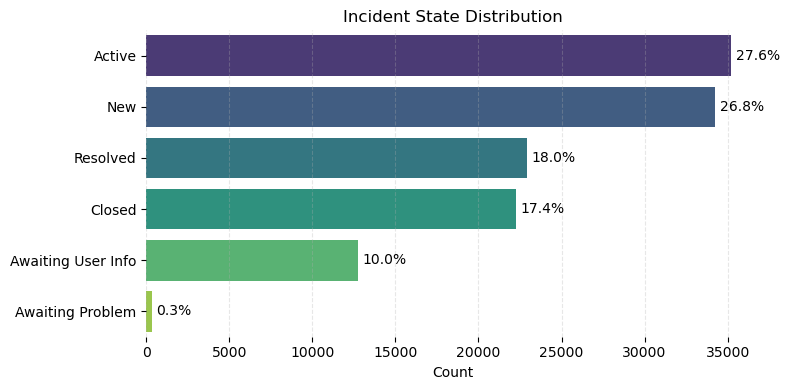

In [96]:
state_count = incident_df["incident_state"].value_counts().head(6).reset_index()
state_count.columns = ["incident_state", "count"]
state_count["percentage"] = (state_count["count"] / state_count["count"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=state_count, x="count", y="incident_state", hue="incident_state", palette="viridis", legend=False, ax=ax)

# adding percentage labels
for i, row in state_count.iterrows():
    ax.text(row["count"] + 300, i, f'{row["percentage"]}%', va="center", fontsize=10)

ax.set_title("Incident State Distribution")
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.xaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


What states are incidents in across the dataset?

The chart shows how incidents are spread across different 
states. Active and New incidents make up over half the 
dataset at 27.6% and 26.8% respectively. This means a 
large portion of incidents were still being worked on 
at the time the data was recorded.

Resolved and Closed incidents make up around 18% and 
17.4% which shows a good number of incidents reached 
their final state.

Awaiting User Info accounts for 10% of incidents — 
these are cases where the support team is waiting for 
the user to respond before the incident can move forward.

This distribution confirms that the dataset is an event 
log capturing incidents at different stages of their 
lifecycle rather than only completed incidents.

## 2. Priority Distribution

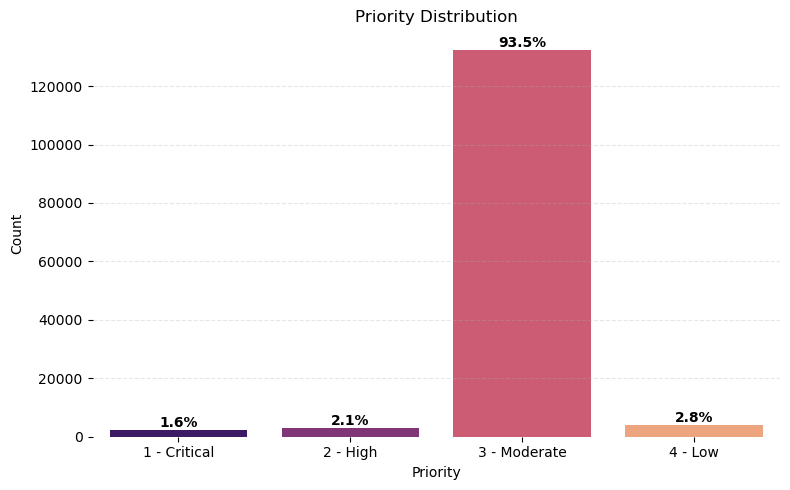

In [72]:
priority_order = ["1 - Critical", "2 - High", "3 - Moderate", "4 - Low"]

# counting incidents per priority and calculating percentage
priority_count = incident_df["priority"].value_counts().reset_index()
priority_count.columns = ["priority", "count"]
priority_count["percentage"] = (priority_count["count"] / priority_count["count"].sum() * 100).round(1)
priority_count["priority"] = pd.Categorical(priority_count["priority"], categories=priority_order, ordered=True)
priority_count = priority_count.sort_values("priority").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=priority_count, x="priority", y="count", hue="priority", palette="magma", legend=False, ax=ax)

# adding percentage labels above each bar
for i, row in priority_count.iterrows():
    ax.text(i, row["count"] + 1000, f'{row["percentage"]}%', ha="center", fontsize=10, fontweight="bold")

ax.set_title("Priority Distribution")
ax.set_xlabel("Priority")
ax.set_ylabel("Count")
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

How are incidents distributed across different priority levels?
Is the data balanced

Looking at the chart, most incidents fall under 3 - Moderate priority. 
The count is over 130,000 which is way higher than the rest.

4 - Low and 2 - High are both quite small, around 3,000 to 5,000 each. 
1 - Critical is the smallest of all four.

This tells me the data is not balanced at all. Almost everything is 
moderate priority. In a real IT support system this kind of makes sense 
because serious problems do not happen that often.

One thing to keep in mind is that this imbalance might cause issues later 
when building the model, since it will mostly learn from moderate cases 
and might struggle with high or critical ones.

## 3. Contact Type Distribution

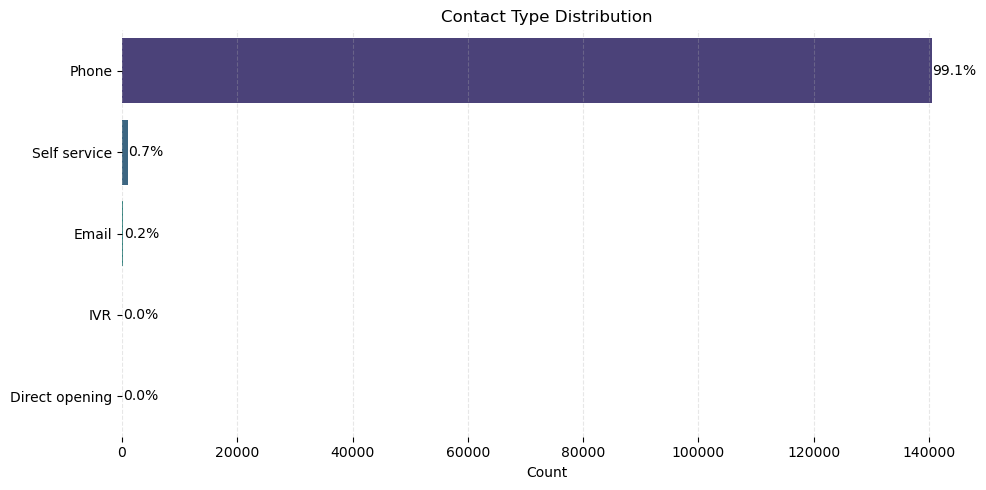

In [73]:
# counting incidents per contact type with percentage
contact_count = incident_df["contact_type"].value_counts().reset_index()
contact_count.columns = ["contact_type", "count"]
contact_count["percentage"] = (contact_count["count"] / contact_count["count"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=contact_count, x="count", y="contact_type", hue="contact_type", palette="viridis", legend=False, ax=ax)

# adding percentage labels
for i, row in contact_count.iterrows():
    ax.text(row["count"] + 100, i, f'{row["percentage"]}%', va="center", fontsize=10)

ax.set_title("Contact Type Distribution")
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.xaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

How are incidents typically raised in the IT support system?

The chart shows that 99.2% of all incidents are raised by Phone. 
Self service accounts for only 0.6% and Email for 0.2%.

This is an extremely imbalanced column. Because almost all 
incidents use the same contact type, this feature may not 
contribute much to the prediction model. This will be 
reviewed during the modelling stage.

## 4. Category Distribution

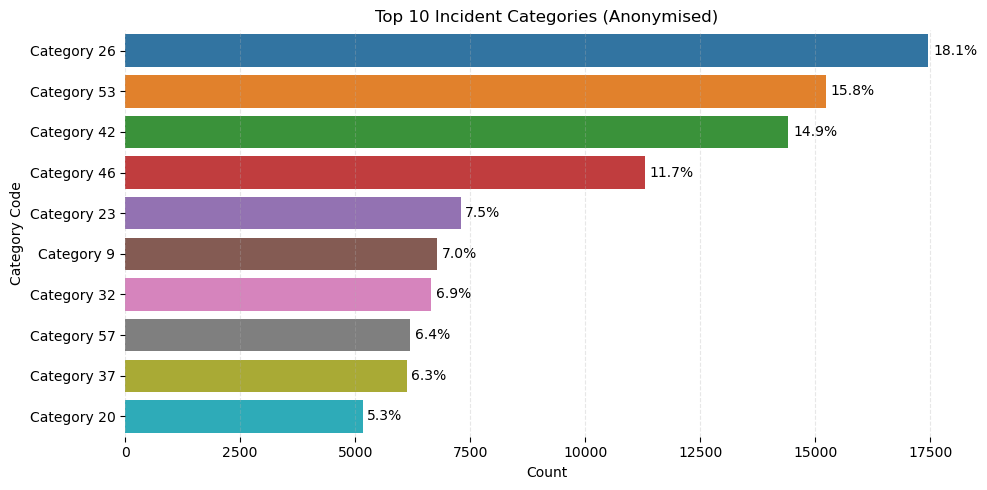

In [159]:
# 4. Category Distribution
category_count = incident_df["category"].value_counts().head(10).reset_index()
category_count.columns = ["category", "count"]
category_count["percentage"] = (category_count["count"] / category_count["count"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=category_count, x="count", y="category", hue="category", palette="tab10", legend=False, ax=ax)

for i, row in category_count.iterrows():
    ax.text(row["count"] + 100, i, f'{row["percentage"]}%', va="center", fontsize=10)

ax.set_title("Top 10 Incident Categories (Anonymised)")
ax.set_xlabel("Count")
ax.set_ylabel("Category Code")
ax.xaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

The chart shows the top 10 most frequent incident categories in the dataset. 
The category values have been anonymised and are represented as coded identifiers 
rather than descriptive labels. Despite this, clear variation exists across the 
category codes. Category 26 is the most common accounting for 18.1% of incidents, 
followed by Category 53 at 15.8% and Category 42 at 14.9%. The remaining categories 
each account for under 12% of incidents.

This variation confirms that category carries useful information about the type of 
incident raised and justifies its inclusion as a feature in the prediction model. 
Since the values are anonymous codes with no natural order, label encoding is applied 
during data preparation rather than one-hot encoding, as applying one-hot encoding 
to 52 unique category codes would create excessive additional columns and add 
unnecessary noise to the dataset.

## 5. SLA Compliance by Priority

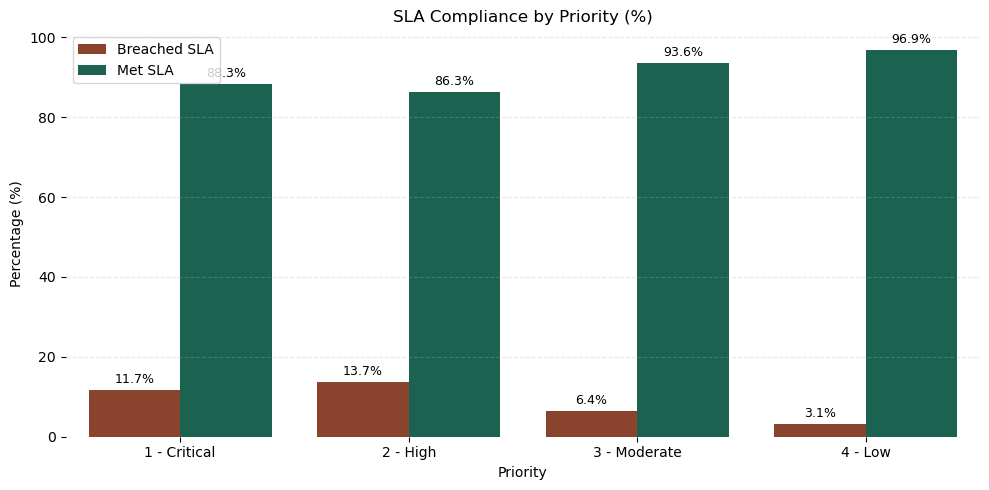

In [74]:
# calculating SLA compliance percentage by priority
sla_priority = incident_df.groupby("priority")["made_sla"].value_counts(normalize=True).mul(100).reset_index()
sla_priority.columns = ["priority", "made_sla", "percentage"]

priority_order = ["1 - Critical", "2 - High", "3 - Moderate", "4 - Low"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=sla_priority, x="priority", y="percentage", hue="made_sla", order=priority_order, palette={True: "#0F6E56", False: "#993C1D"}, ax=ax)

# adding percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9, padding=3)

# fixing legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Breached SLA", "Met SLA"])

ax.set_title("SLA Compliance by Priority (%)")
ax.set_xlabel("Priority")
ax.set_ylabel("Percentage (%)")
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


Do higher priority incidents breach the SLA more often than 
lower priority ones?

To investigate this, the SLA compliance rate was calculated 
for each priority level and plotted as a percentage so that 
all priority levels could be compared fairly regardless of 
how many incidents each one has.

From the chart it can be observed that 2 - High incidents 
have the highest SLA breach rate at 13.7%, followed by 
1 - Critical at 11.6%. This makes sense because high and 
critical priority incidents are often more complex and 
harder to resolve quickly.

3 - Moderate incidents have a breach rate of only 6.0% and 
4 - Low incidents have the lowest breach rate at 2.2%. This 
confirms that lower priority incidents are generally resolved 
within the agreed time.

This is an important finding because it shows that priority 
level directly influences whether an incident meets its SLA. 
This supports the inclusion of priority as a feature in the 
prediction model.

## 6. Correlation Numeric Features

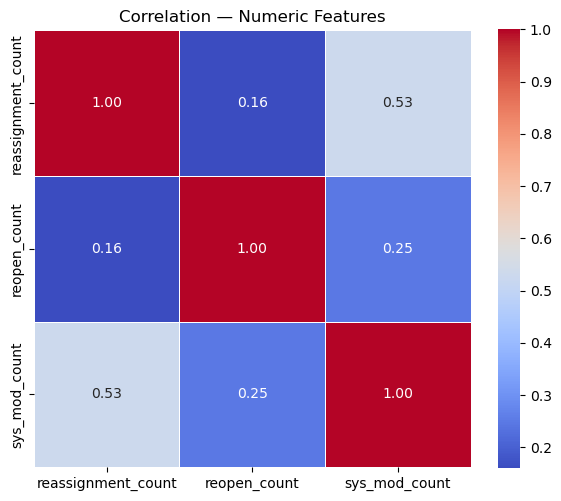

In [75]:
# selecting numeric columns for correlation
num_cols = ["reassignment_count", "reopen_count", "sys_mod_count"]
corr = incident_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, ax=ax, square=True)
ax.set_title("Correlation — Numeric Features")
plt.tight_layout()
plt.show()

Is there any relationship between the numeric features in the dataset?

A correlation heatmap was created to check if any of the three numeric 
columns are related to each other.

From the heatmap it can be observed that reassignment_count and 
sys_mod_count have a moderate correlation of 0.53. This makes sense 
because incidents that get reassigned more times will likely have more 
system updates as well.

reopen_count has a weak correlation with both reassignment_count at 0.16 
and sys_mod_count at 0.25 respectively.

Overall the correlations suggest that reassignment_count and sys_mod_count 
are moderately related while reopen_count behaves more independently.

## Outlier Check Numeric Columns

In [76]:
# checking for outliers in numeric columns
num_cols = ["reassignment_count", "reopen_count", "sys_mod_count"]
incident_df[num_cols].describe()

,reassignment_count,reopen_count,sys_mod_count
count,141712.000000,141712.000000,141712.000000
mean,1.104197,0.021918,5.080946
std,1.734673,0.207302,7.680652
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000
50%,1.000000,0.000000,3.000000
75%,1.000000,0.000000,6.000000
max,27.000000,8.000000,129.000000


Do any of the numeric columns contain extreme values 
that could affect the model?

The describe() function was used to check the minimum, 
maximum and quartile values for the three numeric columns.

Looking at reassignment_count, 75% of incidents have a 
value of 1 or less but the maximum is 20. This means a 
small number of incidents were reassigned many times.

reopen_count has a mean of only 0.018 and a maximum of 8 
meaning most incidents are never reopened and only a very 
small number are reopened multiple times.

sys_mod_count has a mean of 4.1 but a maximum of 82 which 
is quite high. This suggests some incidents had a very 
large number of system updates which could be outliers.

These extreme values confirm that outliers exist in the 
numeric columns and will need to be handled carefully 
during Stage 2 data preparation.

## 7. Reassignment Count Distribution

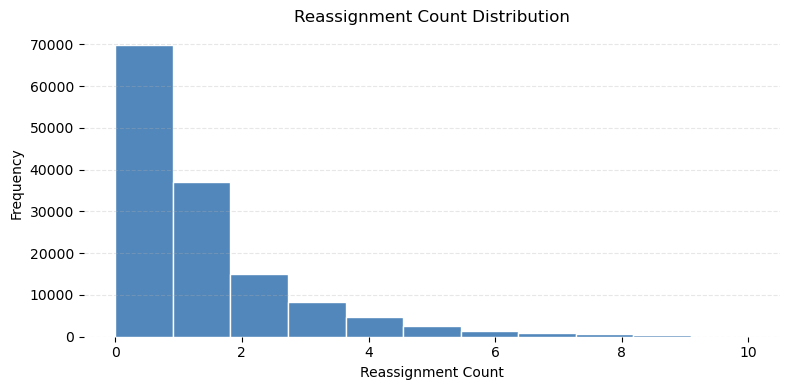

In [77]:
# filtering to reassignment count <= 10 to focus on most common values
filtered_data = incident_df[incident_df["reassignment_count"] <= 10]

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(filtered_data["reassignment_count"], bins=11, color="#185FA5", edgecolor="white", ax=ax)
ax.set_title("Reassignment Count Distribution")
ax.set_xlabel("Reassignment Count")
ax.set_ylabel("Frequency")
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

How many times are incidents typically reassigned before 
they are resolved?

The histogram shows that the majority of incidents have a 
reassignment count of 0 or 1, meaning most incidents are 
handled by the first team they are assigned to without 
being passed on.

A small number of incidents have higher reassignment counts 
which suggests they are more complex and require multiple 
teams to handle them.

The histogram is filtered to show only incidents with 10 or 
fewer reassignments to focus on the most common cases. 
Incidents beyond this range are rare outliers.

## 8. Priority, Impact and Urgency vs Reassignment Count

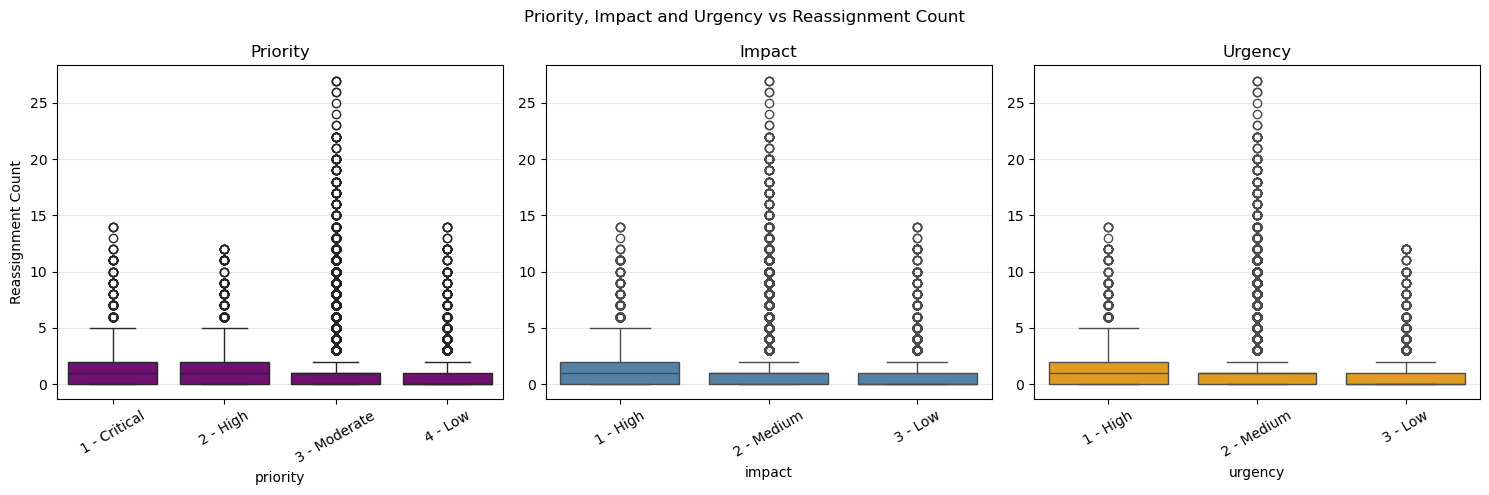

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# defining correct order for each category
priority_order = ["1 - Critical", "2 - High", "3 - Moderate", "4 - Low"]
impact_order = ["1 - High", "2 - Medium", "3 - Low"]
urgency_order = ["1 - High", "2 - Medium", "3 - Low"]

# plotting boxplots for priority, impact and urgency vs reassignment count
sns.boxplot(data=incident_df, x="priority", y="reassignment_count", order=priority_order, ax=axes[0], color="purple")
sns.boxplot(data=incident_df, x="impact", y="reassignment_count", order=impact_order, ax=axes[1], color="steelblue")
sns.boxplot(data=incident_df, x="urgency", y="reassignment_count", order=urgency_order, ax=axes[2], color="orange")

# setting titles
axes[0].set_title("Priority")
axes[1].set_title("Impact")
axes[2].set_title("Urgency")

# setting axis labels
axes[0].set_ylabel("Reassignment Count")
axes[1].set_ylabel("")
axes[2].set_ylabel("")

# rotating x axis labels
axes[0].tick_params(axis="x", rotation=30)
axes[1].tick_params(axis="x", rotation=30)
axes[2].tick_params(axis="x", rotation=30)

# adding grid lines
axes[0].grid(axis="y", alpha=0.3)
axes[1].grid(axis="y", alpha=0.3)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Priority, Impact and Urgency vs Reassignment Count")
plt.tight_layout()
plt.show()

Do more serious incidents get reassigned more often than 
less serious ones?

The boxplots show the reassignment count distribution 
across different levels of priority, impact and urgency.

It can be observed that 1 - Critical and 2 - High priority 
incidents have slightly larger boxes and longer whiskers 
compared to 3 - Moderate and 4 - Low. This suggests that 
more serious incidents tend to get reassigned slightly more 
often, which makes sense as critical issues are often more 
complicated and may need different teams to handle them.

For impact, 1 - High impact incidents show a wider spread 
compared to 2 - Medium and 3 - Low, confirming that high 
impact incidents are harder to handle.

For urgency, 1 - High urgency incidents also show a slightly 
larger spread compared to Medium and Low urgency cases.

However the overall difference across all three features is 
not very large. Most incidents have a reassignment count of 
0 to 2 regardless of how serious they are. This tells us 
that while seriousness has some influence on reassignment, 
it is not the only factor.

## Understanding Incident Structure

In [79]:
# checking how many times each incident appears
incident_df["number"].value_counts().head(10)

number
INC0019396    58
INC0044260    56
INC0005927    46
INC0020718    45
INC0011206    44
INC0025734    43
INC0007349    43
INC0012815    40
INC0003419    38
INC0032450    38
Name: count, dtype: int64

In [80]:
# checking total number of unique incidents in the dataset
incident_df["number"].nunique()

24918

To understand the structure of the dataset, the number of occurrences of each incident was checked.

It was found that the same incident number appears multiple times. For example, some incidents appear more than 50 times.

The dataset contains 24,918 unique incidents, while the total number of rows is much higher.

This shows that the dataset is not a simple one-row-per-incident dataset, but an event log, where each row represents an update or change in an incident.

This is important because it affects how the data will be prepared for modeling.

This means that a decision will be needed later on whether to use event-level data or convert it into one row per incident for modeling.

## Duplicate Row Check

In [81]:
# checking exact duplicate rows
incident_df.duplicated().sum()

0

Checking for exact duplicate rows came back as 0.

This means even though the same incident number appears many times, 
each row is actually different. The rows differ because each one 
captures a different state or update at a different point in time.

So the repeated rows are not a data quality issue, they are just 
how the event log works.

## Initial Target Direction

Based on what I have seen so far, the plan is to predict how long an 
incident takes to resolve. This is called resolution time.

The columns opened_at and resolved_at can be used to calculate this. 
The difference between these two timestamps will give the time taken 
to resolve each incident in hours.

This calculated value will become the target variable in Stage 2.

One thing to note is that resolved_at has 3,141 missing values which 
were found earlier. Rows where resolved_at is missing cannot be used 
to calculate resolution time so they will need to be removed in 
Stage 2.

<h2 style="color:#2F5597;font-size:36px ">Data Preparation</h2>

## Replacing Hidden Missing Values

In the dataset, missing values were represented using the `"?"` symbol instead of proper null values.

To ensure accurate data cleaning and analysis, these values are replaced with `NaN`.

In [82]:
# replacing ? with proper missing values NaN
incident_df = incident_df.replace("?", pd.NA)

In [83]:
# checking missing values again after replacement
incident_df.isnull().sum().sort_values(ascending=False)

caused_by                  141689
vendor                     141468
cmdb_ci                    141267
rfc                        140721
problem_id                 139417
sys_created_at              53076
sys_created_by              53076
u_symptom                   32964
assigned_to                 27496
assignment_group            14213
opened_by                    4835
resolved_at                  3141
closed_code                   714
resolved_by                   226
subcategory                   111
category                       78
location                       76
caller_id                      29
priority                        0
notify                          0
u_priority_confirmation         0
knowledge                       0
number                          0
urgency                         0
impact                          0
incident_state                  0
contact_type                    0
sys_updated_at                  0
sys_updated_by                  0
opened_at     

## Missing Values After Replacement

After replacing `"?"` with `NaN`, the missing values in the dataset became clearly visible.

It was observed that several columns contain a very high number of missing values. For example, columns such as `caused_by`, `vendor`, `cmdb_ci`, `rfc`, and `problem_id` have missing values in almost all rows.

Some columns, including `sys_created_at`, `sys_created_by`, `u_symptom`, `assigned_to`, and `assignment_group`, contain a moderate number of missing values.

On the other hand, important columns such as `priority`, `impact`, `urgency`, and `incident_state` do not contain missing values and can be used reliably for analysis.

This step is important because it reveals the true data quality and helps in deciding how to handle missing values in the next steps.

## Removing Highly Missing Columns

In [84]:
# dropping columns with too many missing values
incident_df = incident_df.drop(
    columns=["caused_by", "vendor", "cmdb_ci", "rfc", "problem_id"]
)

In [85]:
# checking missing values again after dropping columns
incident_df.isnull().sum().sort_values(ascending=False)

sys_created_at             53076
sys_created_by             53076
u_symptom                  32964
assigned_to                27496
assignment_group           14213
opened_by                   4835
resolved_at                 3141
closed_code                  714
resolved_by                  226
subcategory                  111
category                      78
location                      76
caller_id                     29
impact                         0
priority                       0
urgency                        0
u_priority_confirmation        0
notify                         0
knowledge                      0
number                         0
incident_state                 0
contact_type                   0
sys_updated_at                 0
sys_updated_by                 0
opened_at                      0
made_sla                       0
sys_mod_count                  0
reopen_count                   0
reassignment_count             0
active                         0
closed_at 

Based on the missing value analysis, some columns contain missing values in almost all rows.

Columns such as `caused_by`, `vendor`, `cmdb_ci`, `rfc`, and `problem_id` have more than 99% missing values and do not provide useful information.

These columns were removed to improve data quality and reduce noise in the dataset.

## Datetime Conversion

In [86]:
# converting date columns to datetime with correct format
incident_df["opened_at"]    = pd.to_datetime(incident_df["opened_at"],     dayfirst=True, errors="coerce")
incident_df["resolved_at"]  = pd.to_datetime(incident_df["resolved_at"],   dayfirst=True, errors="coerce")
incident_df["closed_at"]    = pd.to_datetime(incident_df["closed_at"],     dayfirst=True, errors="coerce")
incident_df["sys_updated_at"]= pd.to_datetime(incident_df["sys_updated_at"],dayfirst=True, errors="coerce")

# checking updated data types
incident_df[["opened_at","resolved_at","closed_at","sys_updated_at"]].dtypes

opened_at         datetime64[ns]
resolved_at       datetime64[ns]
closed_at         datetime64[ns]
sys_updated_at    datetime64[ns]
dtype: object

The columns `opened_at`, `resolved_at`, and `closed_at` were converted from object type to datetime format using the correct day-first format.

The parameter `dayfirst=True` ensures that the dates are interpreted correctly as day/month/year.

The parameter `errors="coerce"` converts any invalid or inconsistent date values into missing values.

After conversion, all three columns are now in datetime format, which allows time-based calculations such as incident resolution time in the next step.

## Creating the Target Variable

In [87]:
# creating incident resolution time in hours
incident_df["resolution_time_hours"]=(incident_df["resolved_at"]-incident_df["opened_at"]).dt.total_seconds()/3600

# checking first few rows of the new target column
incident_df[["opened_at","resolved_at","resolution_time_hours"]].head()

,opened_at,resolved_at,resolution_time_hours
0,2016-02-29 01:16:00,2016-02-29 11:29:00,10.216667
1,2016-02-29 01:16:00,2016-02-29 11:29:00,10.216667
2,2016-02-29 01:16:00,2016-02-29 11:29:00,10.216667
3,2016-02-29 01:16:00,2016-02-29 11:29:00,10.216667
4,2016-02-29 04:40:00,2016-03-01 09:52:00,29.200000


A new column called `resolution_time_hours` was created by calculating the difference between `resolved_at` and `opened_at`.

The time difference was converted into hours so it is easier to understand and use later in the model.

From the output, it can be seen that the values are positive and look correct, which means the calculation has been done properly.

This column will be used as the target variable to predict how long it takes to resolve an incident.

## Handling Missing Values in Target Variable

In [88]:
# checking missing values in target
incident_df["resolution_time_hours"].isnull().sum()

3141

In [89]:
# removing rows where target is missing
incident_df=incident_df.dropna(subset=["resolution_time_hours"])

# checking again after removal
incident_df["resolution_time_hours"].isnull().sum()

0

The target variable was checked for missing values. It was found that 
there were 3,141 missing values in resolution_time_hours. These rows 
were removed as machine learning models require a complete target variable. 
After removing them, no missing values remain in the target column.

## Checking for Invalid Target Values

In [90]:
# checking negative resolution times
incident_df[incident_df["resolution_time_hours"]<0]

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,closed_code,resolved_by,resolved_at,closed_at,resolution_time_hours


In [91]:
# counting negative values
(incident_df["resolution_time_hours"]<0).sum()

0

In [92]:
# checking zero and extreme outlier values
print("Zero values:      ", (incident_df["resolution_time_hours"] == 0).sum())
print("> 720 hrs (30d):  ", (incident_df["resolution_time_hours"] > 720).sum())

Zero values:       121
> 720 hrs (30d):   10667


In [93]:
# saving copy before outlier removal for visualisation
incident_df_before = incident_df.copy()

# removing zero values and extreme outliers
incident_df = incident_df[incident_df["resolution_time_hours"] > 0]
incident_df = incident_df[incident_df["resolution_time_hours"] <= 720]

print("Rows remaining after cleaning:", incident_df.shape[0])

Rows remaining after cleaning: 127783


The target variable was checked for three types of invalid values.

First, negative values were checked because an incident cannot be resolved before 
it is opened. The result showed that there were no negative values in the dataset.

Second, zero values were checked. It was found that 121 incidents had a resolution 
time of zero, meaning they were resolved in the same minute they were opened. 
These rows are not meaningful for predicting resolution time and were removed.

Third, extreme outliers were checked. It was found that 10,667 incidents took 
more than 720 hours (30 days) to resolve. These cases are not representative of 
normal incident handling and would negatively affect the model if kept.

After removing these invalid rows, 127,783 rows remain in the dataset.

## Reducing to One Row Per Incident
The dataset is an event log with multiple rows per incident. Each row represents 
a state change or update to an incident. For machine learning, the data must be 
reduced to one row per incident.

The last recorded state of each incident is kept as it represents the final 
outcome of the incident.

In [155]:
# keeping the last recorded event per incident
incident_final = incident_df.sort_values("sys_updated_at").groupby("number").last().reset_index()

print("Unique incidents after groupby:", incident_final.shape[0])
print("Columns:", incident_final.shape[1])

Unique incidents after groupby: 22174
Columns: 33


The dataset is an event log where each incident appears multiple times. 
Each row represents a state change or update to an incident rather than 
a single complete incident.

For example, one incident such as INC0000045 may appear four times in the 
dataset, once for each state it went through such as New, Active, Resolved, 
and Closed.

For machine learning, the data must be reduced to one row per incident. 
The rows are first sorted by the last updated time so that the most recent
update is at the bottom. The data is then grouped by incident number and 
the last row of each group is kept.

The last row is kept because it contains the final state of the incident, 
the total reassignment count, and the actual resolution time. These are the 
values that are needed for prediction.

## Log Transformation of Target Variable

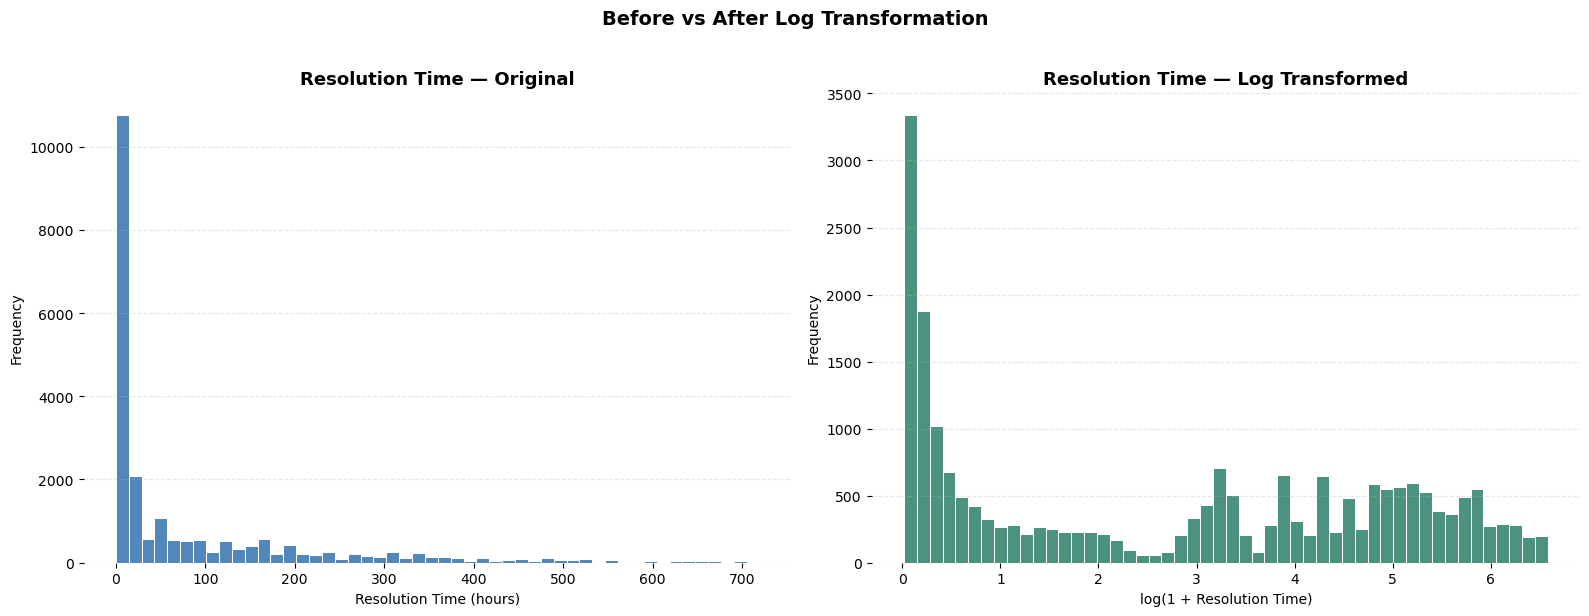

In [131]:
# creating log transformed version of target variable
incident_final["resolution_time_log"] = np.log1p(incident_final["resolution_time_hours"])

# setting up side by side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# original distribution
sns.histplot(incident_final["resolution_time_hours"], bins=50, color="#185FA5", edgecolor="white", ax=axes[0])
axes[0].set_title("Resolution Time — Original", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Resolution Time (hours)")
axes[0].set_ylabel("Frequency")
axes[0].yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(ax=axes[0], left=True, bottom=True)

# log transformed distribution
sns.histplot(incident_final["resolution_time_log"], bins=50, color="#0F6E56", edgecolor="white", ax=axes[1])
axes[1].set_title("Resolution Time — Log Transformed", fontsize=13, fontweight="bold")
axes[1].set_xlabel("log(1 + Resolution Time)")
axes[1].set_ylabel("Frequency")
axes[1].yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(ax=axes[1], left=True, bottom=True)

# adding overall title
plt.suptitle("Before vs After Log Transformation", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

The original distribution is heavily right-skewed with most incidents 
resolved in a short time and a long tail of incidents taking much longer.

After applying log transformation using log1p, the distribution becomes 
much more balanced and spread out across the range.

This is important because many machine learning models perform better 
when the target variable is normally distributed. The log transformed 
version will be used as the target during modelling.

## Resolution Time by Priority

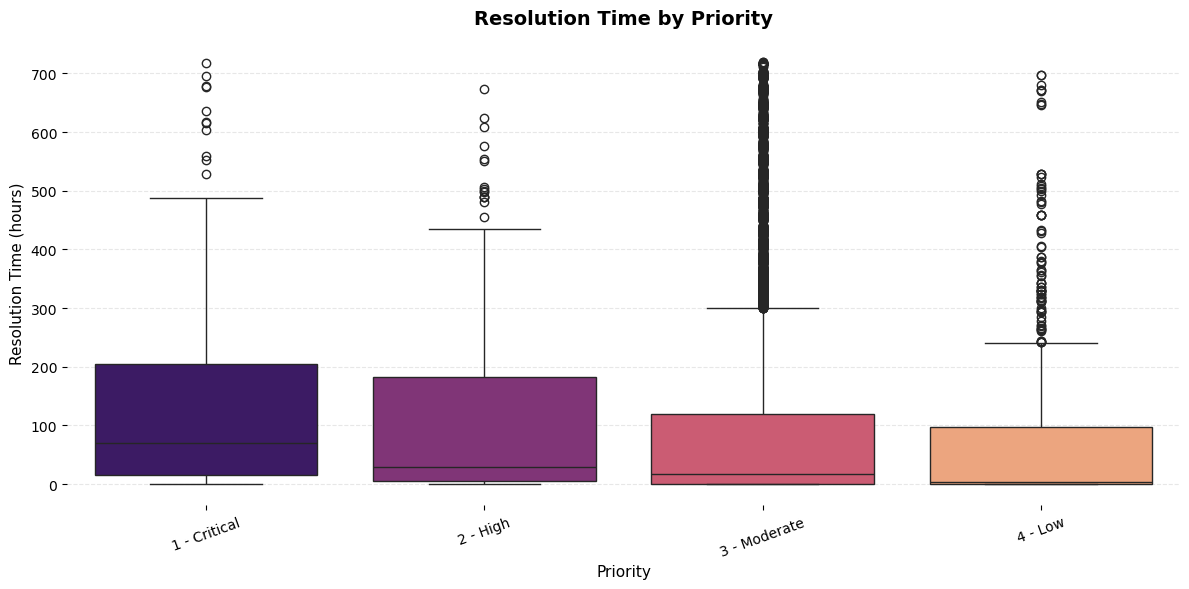

In [132]:
# defining priority order from most to least critical
priority_order = ["1 - Critical", "2 - High", "3 - Moderate", "4 - Low"]

# setting up figure
fig, ax = plt.subplots(figsize=(12, 6))

# plotting boxplot of resolution time by priority
sns.boxplot(data=incident_final, x="priority", y="resolution_time_hours", order=priority_order, hue="priority", hue_order=priority_order, palette="magma", legend=False, ax=ax)

# adding titles and labels
ax.set_title("Resolution Time by Priority", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Priority", fontsize=11)
ax.set_ylabel("Resolution Time (hours)", fontsize=11)

# rotating x axis labels for readability
ax.tick_params(axis="x", rotation=20)

# adding grid and cleaning up chart
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Do higher priority incidents take longer to resolve?

The boxplot shows how resolution time varies across different priority levels.

1 - Critical and 2 - High incidents have the largest boxes and longest 
whiskers, meaning their resolution time varies widely. The dots above 
the whiskers are outliers — incidents that took unusually long to resolve.

3 - Moderate and 4 - Low incidents have smaller boxes meaning they 
resolve within a more consistent time range.

Overall this confirms that priority level influences resolution time 
and is a useful feature for the prediction model.

### Resolution Time vs Reassignment Count

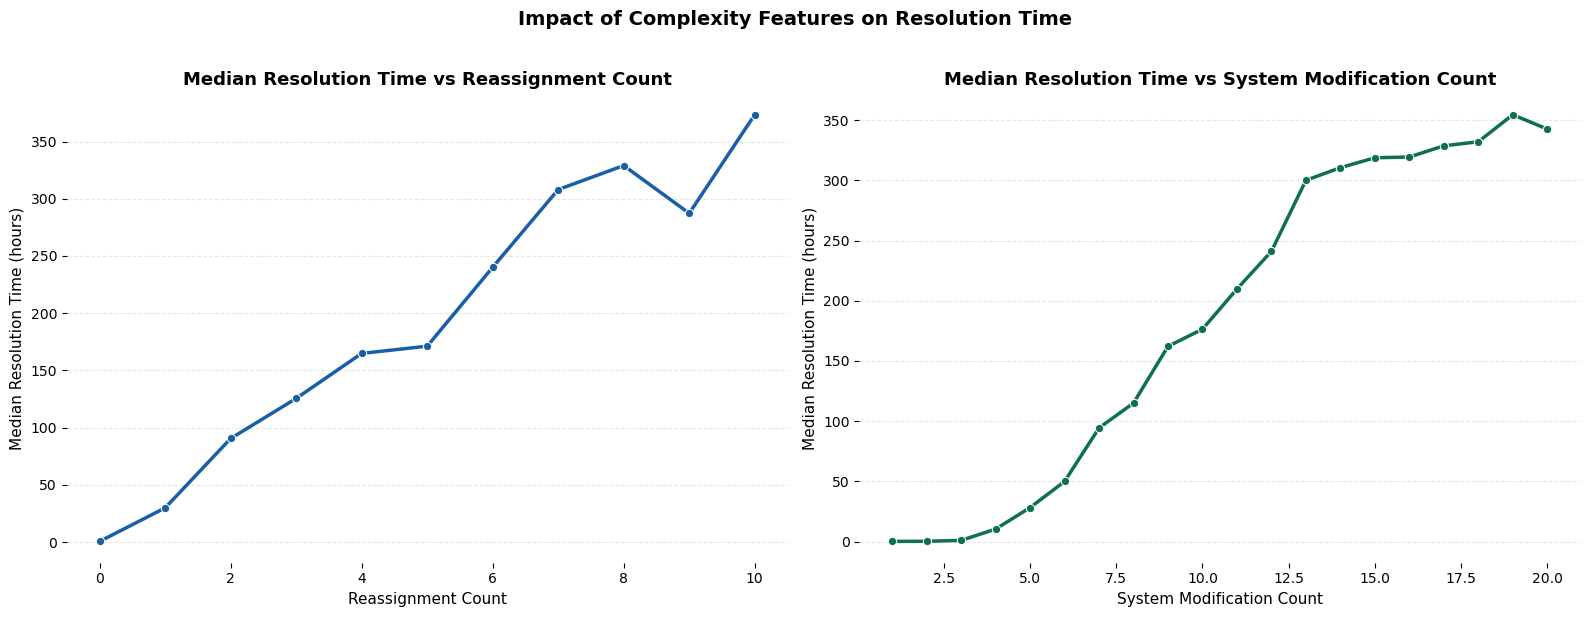

In [153]:
# calculating median resolution time by reassignment count
median_reassignment = incident_final[incident_final["reassignment_count"] <= 10].groupby(
    "reassignment_count")["resolution_time_hours"].median().reset_index()

# calculating median resolution time by sys mod count
median_sysmod = incident_final[incident_final["sys_mod_count"] <= 20].groupby(
    "sys_mod_count")["resolution_time_hours"].median().reset_index()

# setting up side by side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# reassignment count plot
sns.lineplot(data=median_reassignment, x="reassignment_count", y="resolution_time_hours", marker="o", color="#185FA5", linewidth=2.5, ax=axes[0])
axes[0].set_title("Median Resolution Time vs Reassignment Count", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Reassignment Count", fontsize=11)
axes[0].set_ylabel("Median Resolution Time (hours)", fontsize=11)
axes[0].yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(ax=axes[0], left=True, bottom=True)

# sys mod count plot
sns.lineplot(data=median_sysmod, x="sys_mod_count", y="resolution_time_hours",marker="o", color="#0F6E56", linewidth=2.5, ax=axes[1])
axes[1].set_title("Median Resolution Time vs System Modification Count", fontsize=13, fontweight="bold")
axes[1].set_xlabel("System Modification Count", fontsize=11)
axes[1].set_ylabel("Median Resolution Time (hours)", fontsize=11)
axes[1].yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(ax=axes[1], left=True, bottom=True)

plt.suptitle("Impact of Complexity Features on Resolution Time", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

The line plot shows the median resolution time at each reassignment count level.

It can be clearly observed that as the reassignment count increases from 0 to 10, 
the median resolution time increases steadily. Incidents with 0 reassignments 
have a median resolution time of around 20 hours, while incidents that were 
reassigned 10 times have a median resolution time of around 450 hours.

This confirms a strong positive relationship between reassignment count and 
resolution time. The more times an incident is reassigned, the longer it takes 
to resolve. This makes reassignment_count one of the most important features 
for the prediction model.

## Feature Selection
The most relevant features for predicting resolution time are selected based 
on the findings from Stage 1 — Data Understanding and the visualisations 
in Stage 2.

In [147]:
# selecting most relevant features for predicting resolution time
features = [
    "priority",            # severity of the incident
    "impact",              # how many people are affected
    "urgency",             # how quickly it needs to be resolved
    "category",            # type of incident
    "reassignment_count",  # number of times reassigned
    "reopen_count",        # number of times reopened
    "sys_mod_count",       # number of system modifications
]

# using log transformed target variable
target = "resolution_time_log"

# creating final model dataframe
model_df = incident_final[features + [target]].dropna()
print("Final dataset shape:", model_df.shape)
model_df.head()

Final dataset shape: (22168, 8)


,priority,impact,urgency,category,reassignment_count,reopen_count,sys_mod_count,resolution_time_log
0,3 - Moderate,2 - Medium,2 - Medium,Category 55,0,0,4,2.417401
1,3 - Moderate,2 - Medium,2 - Medium,Category 40,1,0,8,3.407842
2,3 - Moderate,2 - Medium,2 - Medium,Category 20,0,0,6,3.079614
3,3 - Moderate,2 - Medium,2 - Medium,Category 9,0,0,3,3.997589
4,2 - High,1 - High,2 - Medium,Category 53,1,0,7,2.290850


Seven features were selected based on findings from Stage 1 and 
the visualisations in Stage 2.

priority, impact and urgency were selected because they directly 
affect how quickly an incident is handled.

reassignment_count, reopen_count and sys_mod_count were selected 
because they measure the complexity of an incident. From the 
analysis it was found that incidents with higher reassignment 
counts and more system modifications take significantly longer 
to resolve.

category provides contextual information about the type of 
incident raised.

made_sla was excluded because it is only known after the incident 
is resolved. Including it would cause data leakage, the model 
would be using information it cannot have at prediction time.

contact_type was excluded because 99.1% of all incidents are 
raised by phone meaning it has almost no variation and would 
not help the model learn anything useful.

## Label Encoding
Categorical columns are converted to numbers so machine learning models can 
process them. Label Encoding assigns a unique integer to each category value.

In [160]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# ordinal columns - order matters (critical > high > moderate > low)
ordinal_cols = ["priority", "impact", "urgency"]
for col in ordinal_cols:
    model_df[col] = le.fit_transform(model_df[col].astype(str))

# category is nominal but has 52 anonymised codes
# label encoding is used to avoid creating 51 extra columns with one-hot encoding
model_df["category"] = le.fit_transform(model_df["category"].astype(str))

print("Data types after encoding:")
print(model_df.dtypes)

Data types after encoding:
priority                 int32
impact                   int32
urgency                  int32
category                 int32
reassignment_count       int64
reopen_count             int64
sys_mod_count            int64
resolution_time_log    float64
dtype: object


Priority, impact and urgency are ordinal variables meaning they have a meaningful 
order — critical is more severe than high, which is more severe than moderate and low. 
Label encoding is appropriate for these columns because the assigned integers preserve 
this natural order.

Category is a nominal variable with no natural ranking between incident types. 
Normally one-hot encoding would be preferred for nominal variables. However in this 
dataset the category values have been anonymised into 52 coded identifiers. Applying 
one-hot encoding would create 51 additional columns which would significantly bloat 
the dataset and add unnecessary noise. Label encoding is therefore used for category 
as well, with the understanding that the model will treat the codes as identifiers 
rather than ordered values. Tree based models such as Random Forest and Decision Tree 
handle this appropriately as they split on values rather than assuming linear order.

The dataset is now fully numeric and ready for the correlation heatmap and modelling.lling.ing.

## Correlation Heatmap of Final Features

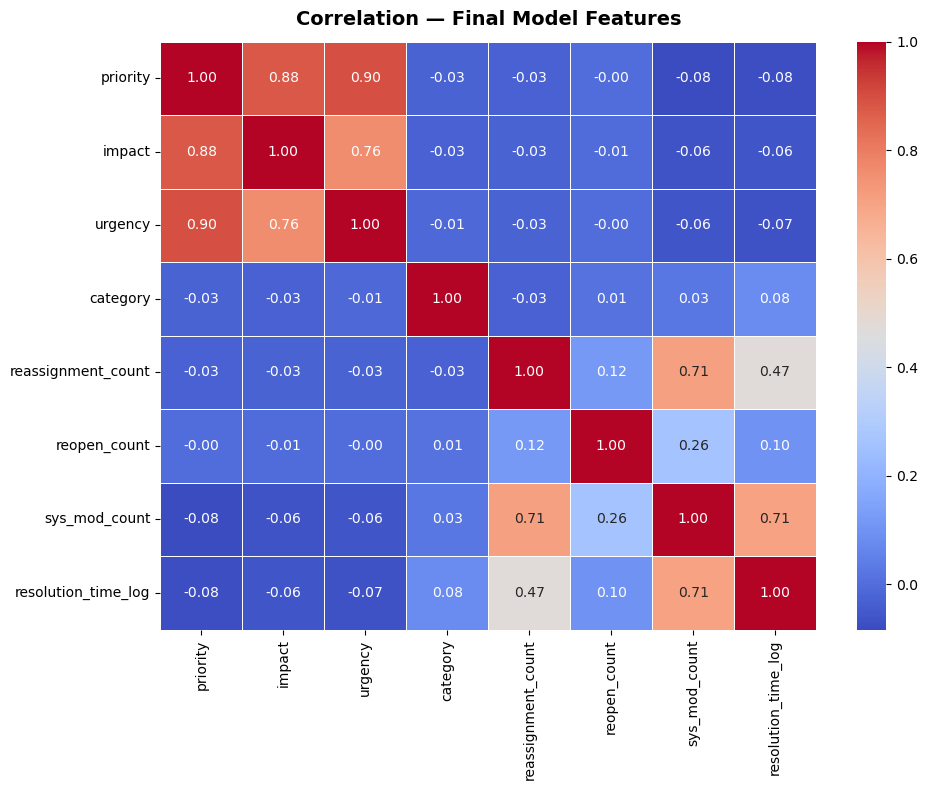

In [161]:
# plotting correlation heatmap of all features and target variable
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(model_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, ax=ax)
ax.set_title("Correlation — Final Model Features", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

The heatmap shows the correlation between all features and the target variable 
resolution_time_log.

sys_mod_count has the strongest positive correlation with resolution time at 0.71, 
confirming that incidents with more system modifications take significantly longer 
to resolve.

reassignment_count shows a moderate correlation of 0.47, supporting the findings 
from the line plot analysis.

reopen_count shows a weak correlation of 0.10.

priority, impact and urgency show very weak negative correlations with resolution 
time. priority and urgency are highly correlated with each other at 0.90 and 
priority and impact at 0.88. This is expected as all three are assigned together 
during incident creation and all measure incident severity in different ways.

While this multicollinearity could be a concern for linear models, tree based 
models such as Random Forest and Decision Tree are not affected as they select 
the best split at each node independently. All three features are therefore 
retained in the final dataset.

## Final Dataset Check Before Modelling

In [150]:
# checking final shape of dataset
print("Final shape:    ", model_df.shape)

# checking for any remaining missing values
print("Missing values: ", model_df.isnull().sum().sum())

# checking summary statistics
model_df.describe()

Final shape:     (22168, 8)
Missing values:  0


,priority,impact,urgency,category,reassignment_count,reopen_count,sys_mod_count,resolution_time_log
count,22168.000000,22168.000000,22168.000000,22168.000000,22168.000000,22168.000000,22168.000000,22168.000000
mean,1.987324,1.008977,1.002256,26.359933,0.949026,0.012450,5.703446,2.684604
std,0.300181,0.210606,0.218044,12.046932,1.517412,0.136093,4.518551,2.199123
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.016529
25%,2.000000,1.000000,1.000000,14.000000,0.000000,0.000000,2.000000,0.312375
50%,2.000000,1.000000,1.000000,27.000000,0.000000,0.000000,4.000000,2.942683
75%,2.000000,1.000000,1.000000,38.000000,1.000000,0.000000,8.000000,4.802791
max,3.000000,2.000000,2.000000,51.000000,20.000000,8.000000,82.000000,6.580454


The final dataset was checked before moving to the modelling stage.

The dataset contains 22,168 incidents with 8 columns  7 features 
and 1 target variable. No missing values remain in the dataset and 
all columns are fully numeric.

sys_mod_count has a mean of 5.70 confirming that incidents go 
through multiple system updates during their lifecycle.

reassignment_count has a mean of 0.95 confirming that most 
incidents are handled by the first team they are assigned to.

The target variable resolution_time_log is the log transformed version 
of resolution time. This was applied because the original distribution 
was heavily right skewed. The log transformation makes it more normally 
distributed and suitable for modelling.